<a href="https://colab.research.google.com/github/OlesiaLelet/Python-projects/blob/main/Exploratory__data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Final project
# Uploading dataset
countries = pd.read_csv("countries.csv")
countries.head()
events = pd.read_csv("events.csv")
print(events.head())
products = pd.read_csv("products.csv")
#products.head()








Mounted at /content/drive
/content/drive/MyDrive/Final project
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  


## Data overview. Розуміння даних та їх змісту.
### Опис датасету:
Набір даних містить інформацію про продажі компанії, яка працює на світовому ринку у період з 1/1/2010 по 9/9/2015 у таблиці "events". Таблиця countries містить інформацію про назви країн, їхні коди, регіони. Таблиця products містить категорії товарів.
### Змінні:
**Таблиця events**:\
*Order ID* - ідентифікатор замовлення;\
*Order Date* - дата замовлення;\
*Ship Date* - дата доставки замовлення;\
*Order Priority* - пріорітетність замовлення;\
*Country Code* - код країни;\
*Product ID* - ідентифікатор продукту;\
*Sales Channel* - канал збуту (онлайн чи офлайн);\
*Units Sold* - кількість проданих товарів;\
*Unit Price* - ціна одиниці товару;\
*Unit Cost* - собівартість одиниці товару;\

**Таблиця products**:\
*id* - ідентифіктор товару;\
*item_type* - категорія товару;

**Таблиця countries**:\
*name* - назва країни;\
*alpha-2* - двохлітерна абревіатура назви країни;\
*alpha-3* - трьохлітерна абревіатура назви країни;\
*region* -  регіон;\
*sub-region* - суб-регіон;

**Ключові поля, що поєднують таблиці:**\
events["Product ID"] = products["id"]\
events["Country Code"] = countries["alpha-3"]





## Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями.
**Таблиця events**\
У стовпці Country Code пропущених значень 6.165414% , що може бути невказання клієнтом країни або через помилку переведення назви країни до alpha-3 коду. Оскільки це категоріальні дані, краще їх заповнити "unknown".\
У стовпці Units Sold пропущених значень лише 0.150376%. Оскільки доля пропущених значень не перевищує 5%, ми можемо видалити ті рядки, які містять пропущені значення.

**Таблиця countries**\
Стовпці alpha-2, region, sub-region містять по 0.401606% пропущених значень. Оскільки це дуже малий відсоток і дані категоріальні, замінюємо пропущені значення на "unknown".

**Таблиця products**\

In [ ]:
# Робота з пропущеними значеннями.
#events.info()
missed_values_events = events.isna().sum()
percent_of_missed_values = (events.isna().sum() / events.shape[0]) * 100
#print(missed_values_events)
#print(percent_of_missed_values)
events.columns = events.columns.str.lower().str.replace(" ", "_")
events["country_code"].fillna("unknown")
events_c = events.dropna()
events_c.info()

#countries.info()
missed_values_countries = countries.isna().sum()
#print(missed_values_countries)
percent_of_missed_values_c = missed_values_countries / countries.shape[0] * 100
#print(percent_of_missed_values_c)
countries_c = countries.fillna("unknown")
countries_c.info()

products.info()
missing_values_products = products.isna().sum()
#print(missing_values_products)

# Перетворення невідповідних типів даних.
events_c["order_date"] = pd.to_datetime(events_c["order_date"])
events_c["ship_date"] = pd.to_datetime(events_c["ship_date"])
print(f"To date time:\n ")
events_c.info()

# Наявність дублікатів.
duplicated_rows_events = events_c.duplicated()
print(f"duplicated_rows_events:\n{duplicated_rows_events.sum()}")
duplicated_rows_countries = countries_c.duplicated()
print(f"duplicated_rows_countries:\n{duplicated_rows_countries.sum()}")
duplicated_rows_products = products.duplicated()
print(f"duplicated_rows_products:\n{duplicated_rows_products.sum()}")

# Наявність аномалій.
events_c.describe()
countries_c.describe()
products.describe()

events_c["sales_channel"] = events_c["sales_channel"].str.lower()
print(events["sales_channel"].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1246 non-null   int64  
 1   order_date      1246 non-null   object 
 2   ship_date       1246 non-null   object 
 3   order_priority  1246 non-null   object 
 4   country_code    1246 non-null   object 
 5   product_id      1246 non-null   int64  
 6   sales_channel   1246 non-null   object 
 7   units_sold      1246 non-null   float64
 8   unit_price      1246 non-null   float64
 9   unit_cost       1246 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 107.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null 

/tmp/ipykernel_6237/1793567848.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_c["order_date"] = pd.to_datetime(events_c["order_date"])
/tmp/ipykernel_6237/1793567848.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_c["ship_date"] = pd.to_datetime(events_c["ship_date"])
/tmp/ipykernel_6237/1793567848.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

## Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів.

In [ ]:
# Об'єднання таблиць.
joined_events_and_countries = pd.merge(events_c, countries_c, left_on="country_code", right_on="alpha-3", how="left")
joined_df = pd.merge(joined_events_and_countries, products, left_on="product_id", right_on="id", how="left")
joined_df = joined_df.drop(["alpha-2", "alpha-3", "id"], axis=1)
#print(joined_df)

# Ключові метрики
joined_df["revenue"] = joined_df["units_sold"] * joined_df["unit_price"]
joined_df["order_cost"] = joined_df["unit_cost"] * joined_df["units_sold"]
joined_df["profit"] = joined_df["revenue"] - joined_df["order_cost"]

total_units_sold = joined_df["units_sold"].sum()
total_revenue = joined_df["revenue"].sum()
total_cost = joined_df["order_cost"].sum()
total_profit = joined_df["profit"].sum()
countries_count = joined_df["name"].unique().shape[0]
total_items_type = joined_df["item_type"].unique().shape[0]
total_orders = joined_df.shape[0]
print(f"Total units sold: {total_units_sold}.\nTotal revenue: {total_revenue}.\nTotal cost: {total_cost}.\nTotal profit: {total_profit}.\nTotal countries: {countries_count}.\nTotal items type: {total_items_type}.\nTotal orders: {total_orders}.")


print(joined_df.info())


Total units sold: 6171671.0.
Total revenue: 1598983761.26.
Total cost: 1125274726.1999998.
Total profit: 473709035.06.
Total countries: 45.
Total items type: 12.
Total orders: 1246.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1246 non-null   int64         
 1   order_date      1246 non-null   datetime64[ns]
 2   ship_date       1246 non-null   datetime64[ns]
 3   order_priority  1246 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1246 non-null   int64         
 6   sales_channel   1246 non-null   object        
 7   units_sold      1246 non-null   float64       
 8   unit_price      1246 non-null   float64       
 9   unit_cost       1246 non-null   float64       
 10  name            1246 non-null   object        
 11  region          1246 non-null 

## Аналіз продажів.
# Аналіз продажів

## Аналіз продажів по категоріях

- Найбільший прибуток приносять категорії:
  - **Cosmetics** — 88,010,907.56$  

  - **Office Supplies** — 73,411,976.25$

  - **Household** — 69,160,454.84$

**Рекомендація:** розширювати асортимент та товарні запаси саме цих категорій.

- Найменший прибуток приносить категорія:y
  - **Fruits** — 1,280,035.35$

**Рекомендація:** знижувати товарні запаси та поступово виводити категорію з продажу.

- Найбільшим попитом за кількістю проданих одиниць користуються категорії:
  - **Office Supplies** — 581,481
  - **Clothes** — 579,313
  - **Beverages** — 577,991

**Рекомендація:** підтримувати велику кількість товарних запасів цих категорій.

---

## Аналіз продажів по країнах

- Найбільші виторги приносять країни:
  - **Czech Republic** — 53,543,932.14$  

  - **Ukraine** — 53,252,317.54$  

  - **Bosnia and Herzegovina** — 50,117,508.49$

- Найбільший прибуток мають країни:
  - **Andorra** — 15,410,036.63$  

  - **Ukraine** — 14,804,925.74$  

  - **Malta** — 14,610,127.88$

**Рекомендація:** вкладати більше інвестицій у ці країни та розвивати мережу бізнесу.

---

## Аналіз продажів по регіонах

- Найбільші виторги та прибутки приносить регіон:
  - **Europe**
    - Виторг: 1.505653e+09$  

    - Прибуток: 4.485568e+08$

**Рекомендація:** продовжувати вкладати інвестиції у цей добре розвинений регіон.

---

## Аналіз продажів по каналах

- Виторги між каналами відрізняються незначно:
  - **Offline** — 8.100305e+08$  

  - **Online** — 7.889533e+08$

- Прибутки також практично не відрізняються:
  - **Offline** — 2.385113e+08$  
  
  - **Online** — 2.351977e+08$


Revenue by items group:
          item_type       revenue
8   Office Supplies  3.786662e+08
6         Household  2.788744e+08
4         Cosmetics  2.213054e+08
7              Meat  2.013398e+08
0         Baby Food  1.338344e+08
2            Cereal  9.467672e+07
11       Vegetables  8.203849e+07
10           Snacks  6.921349e+07
3           Clothes  6.330732e+07
9     Personal Care  4.334632e+07
1         Beverages  2.742567e+07
5            Fruits  4.955490e+06.
Profit by item group:
          item_type       profit
4         Cosmetics  88010907.56
8   Office Supplies  73411976.25
6         Household  69160454.84
0         Baby Food  50256042.90
3           Clothes  42544746.72
2            Cereal  40774964.94
11       Vegetables  33617356.30
7              Meat  27297727.60
10           Snacks  25012661.94
9     Personal Care  13290821.60
1         Beverages   9051339.06
5            Fruits   1280035.35.
Order cost by item group:
          item_type    order_cost
8   Office Supplies  

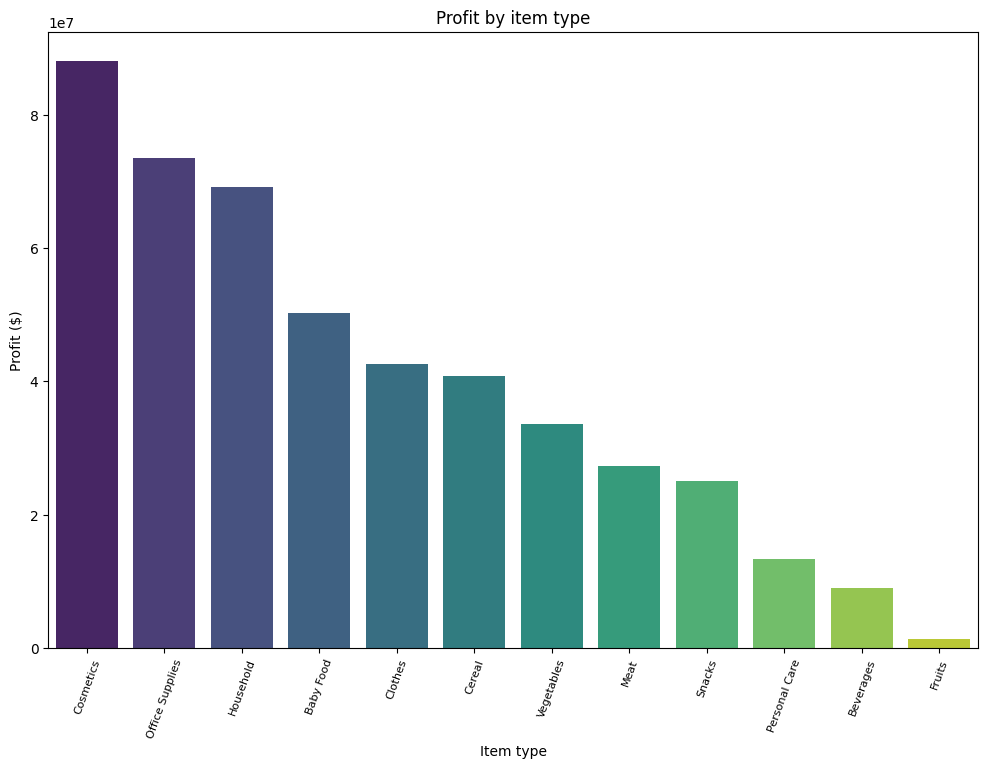

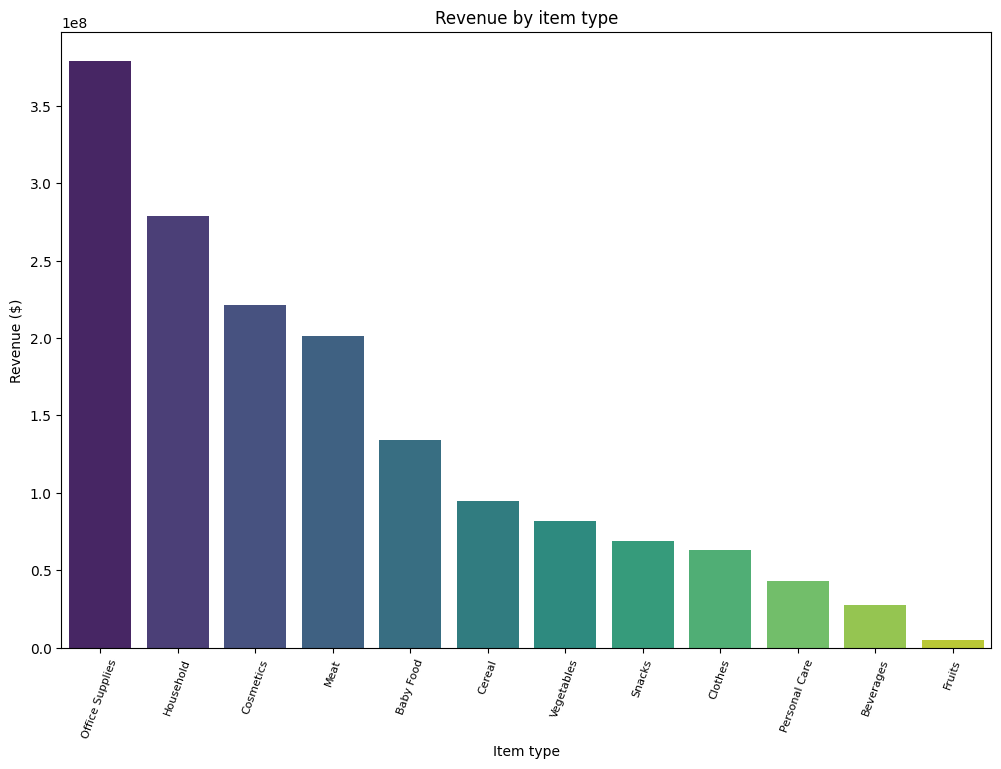

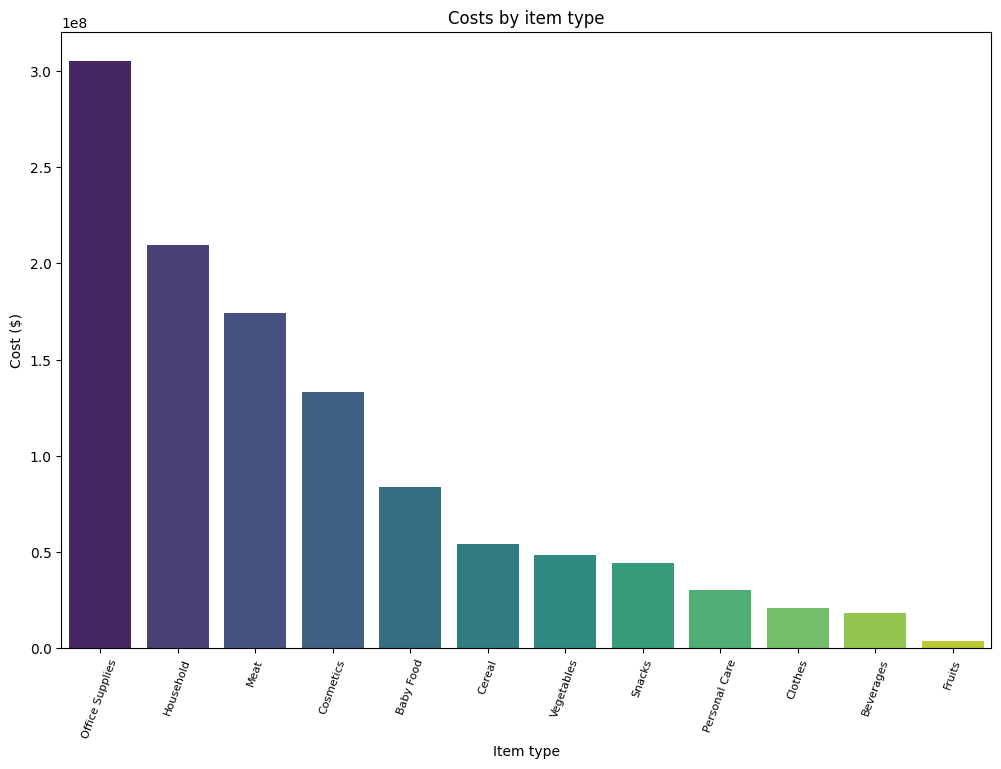

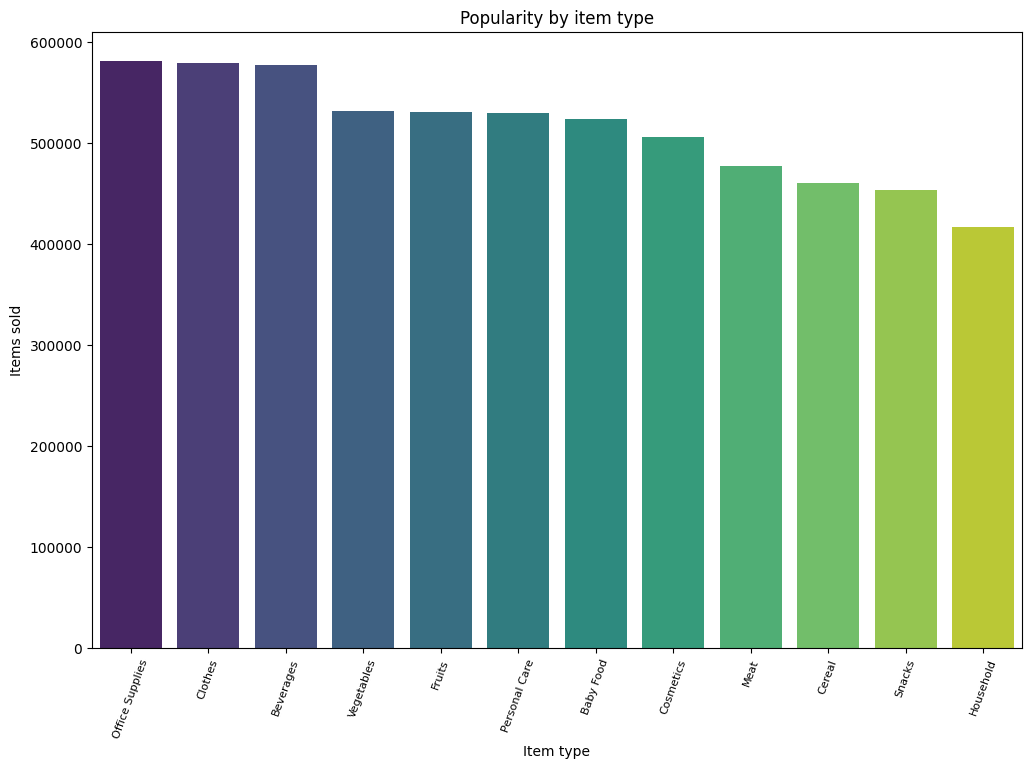

Revenue by countries:
                      name      revenue
10          Czech Republic  53543932.14
43                 Ukraine  53252317.54
6   Bosnia and Herzegovina  50117508.49
26               Macedonia  49222085.25
36              San Marino  47883708.48
1                  Andorra  47756693.17
33                Portugal  47172189.84
27                   Malta  47145320.81
35                  Russia  46051659.81
38                Slovakia  42940998.32.
Profit by countries:
                      name       profit
1                  Andorra  15410036.63
43                 Ukraine  14804925.74
27                   Malta  14610127.88
36              San Marino  13792992.81
18                 Hungary  13786231.03
26               Macedonia  13684099.95
10          Czech Republic  13635593.78
35                  Russia  13267682.64
6   Bosnia and Herzegovina  13257602.77
17                  Greece  12324450.13.
Order cost by countries:
                      name   order_cost
10        

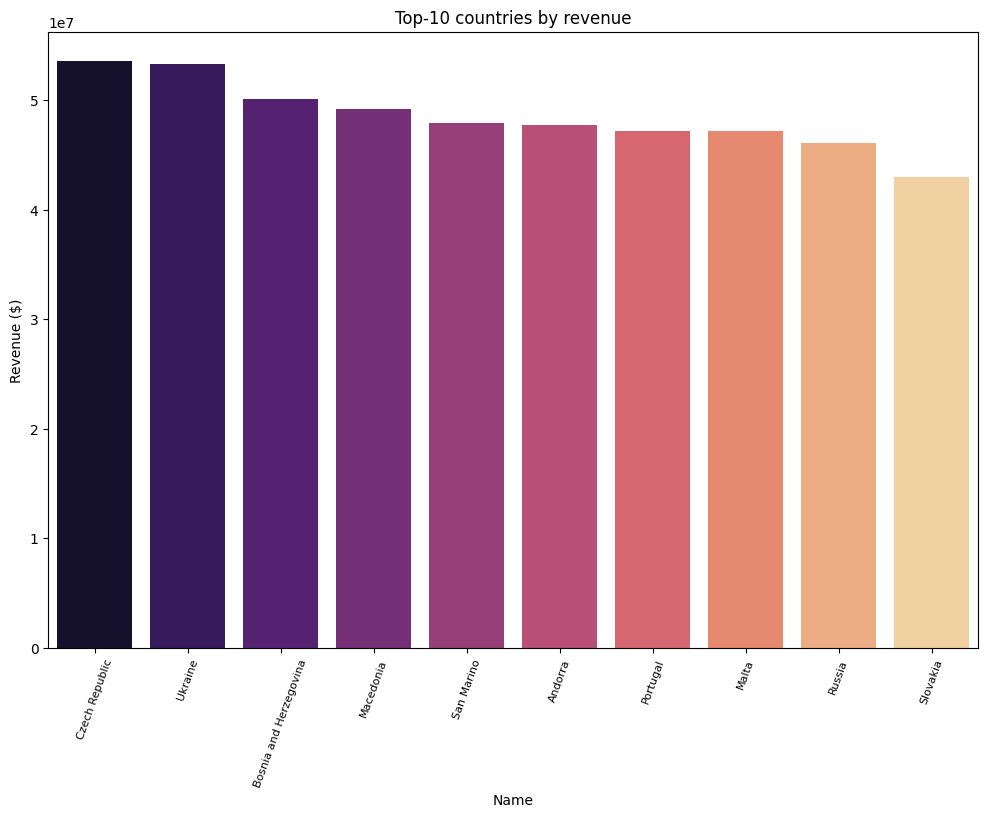

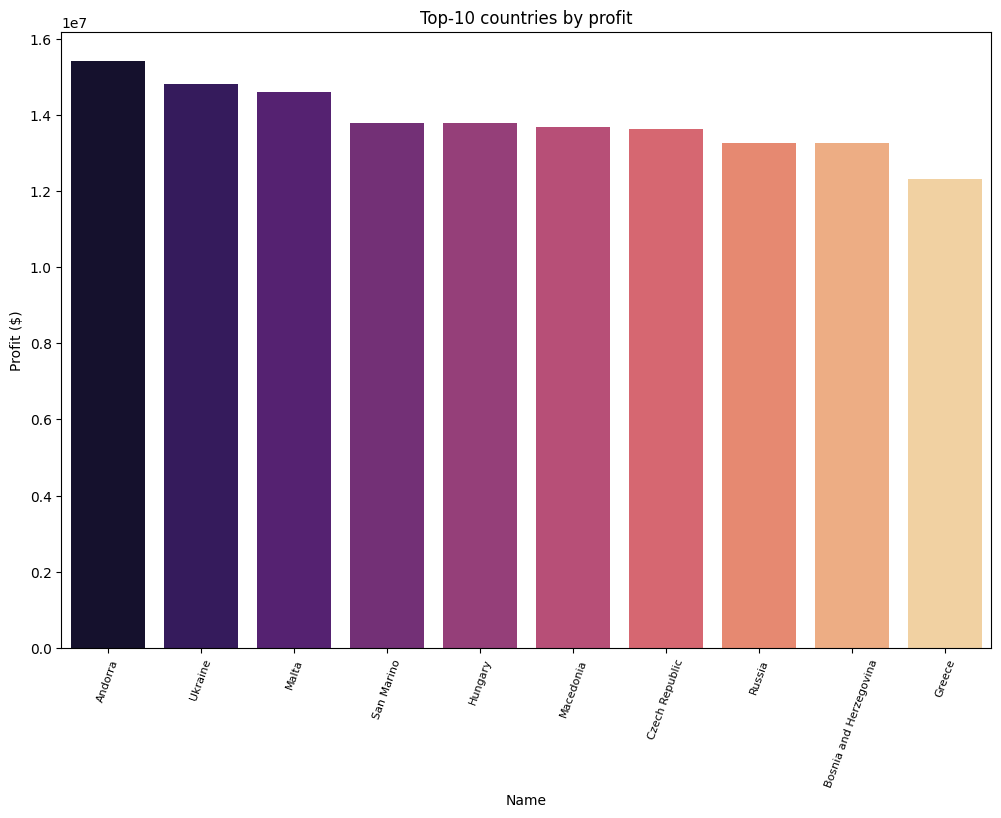

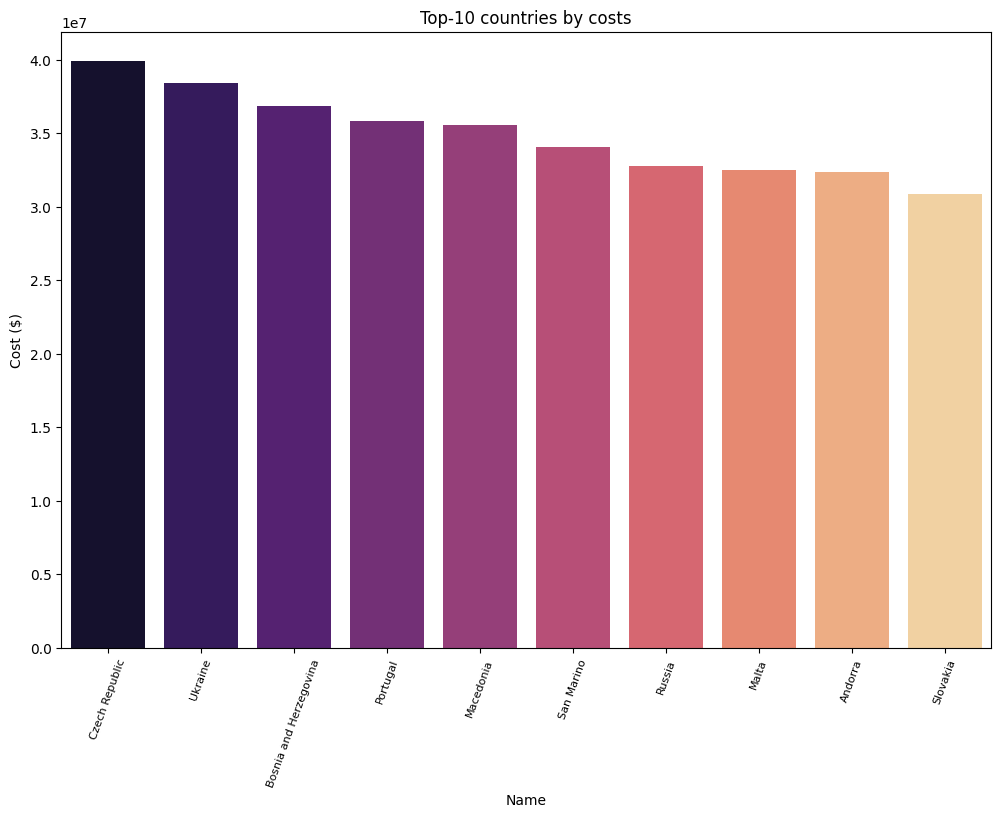

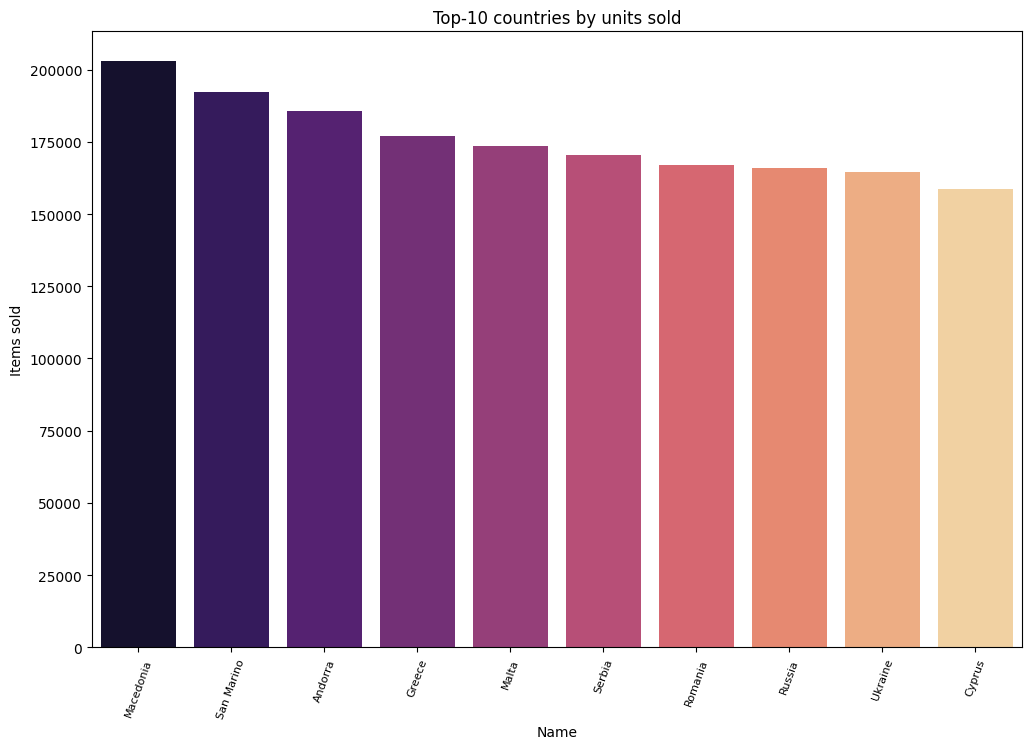

<Figure size 640x480 with 0 Axes>

Revenue by regions:
   region       revenue
1  Europe  1.505653e+09
0    Asia  9.333089e+07.
Profit by regions:
   region        profit
1  Europe  4.485568e+08
0    Asia  2.515225e+07.
Order cost by regions:
   region    order_cost
1  Europe  1.057096e+09
0    Asia  6.817863e+07.
Popularity by regions:
   region  units_sold
1  Europe   5761244.0
0    Asia    410427.0.


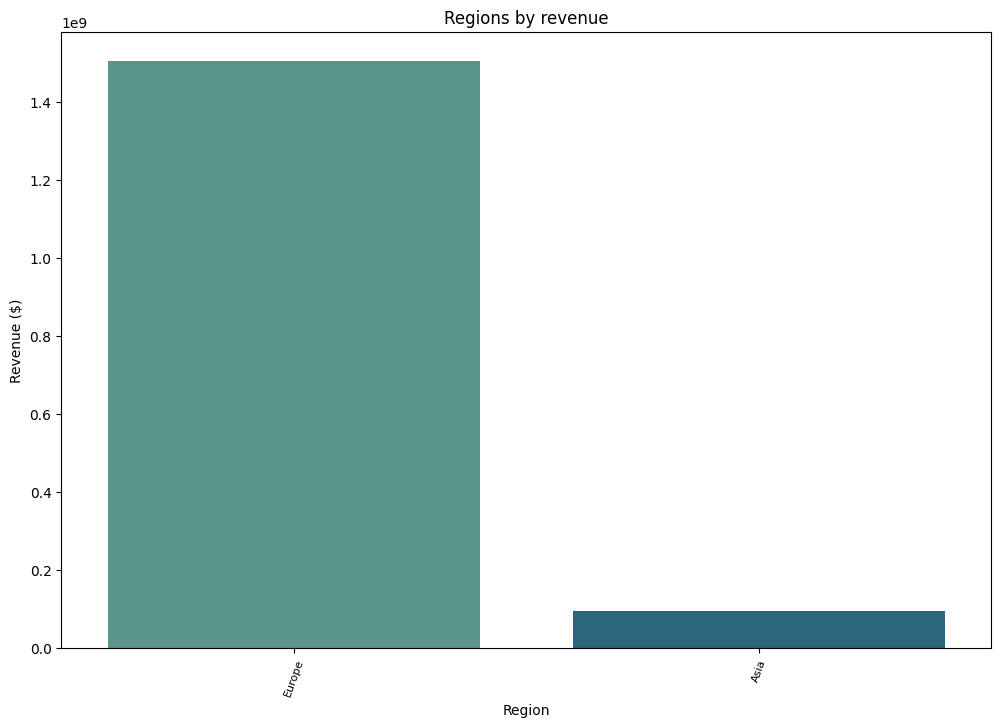

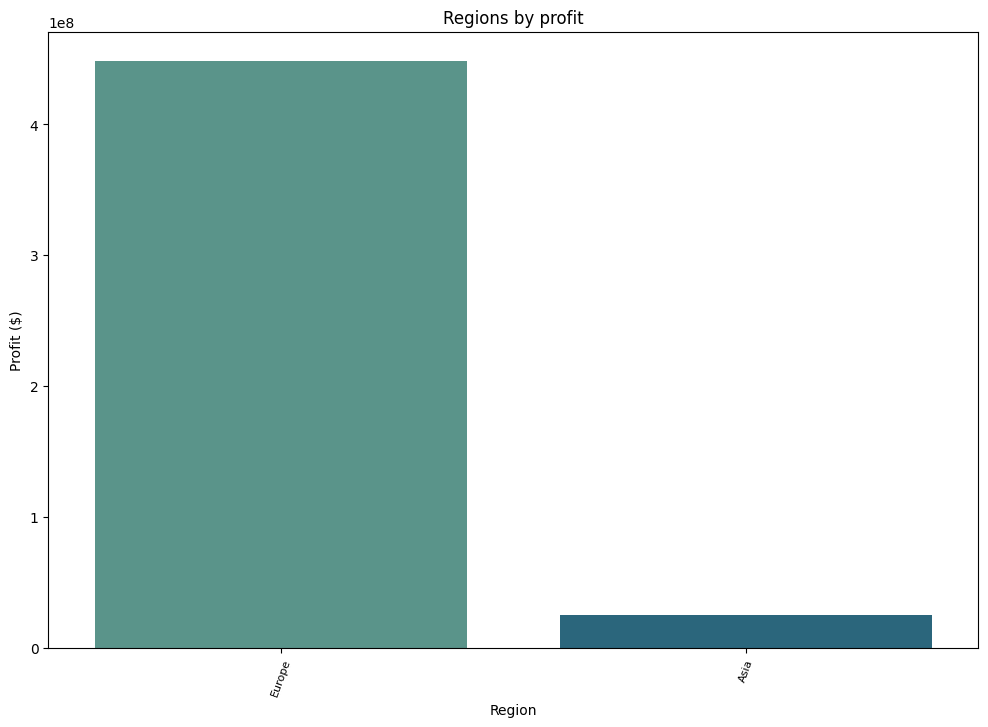

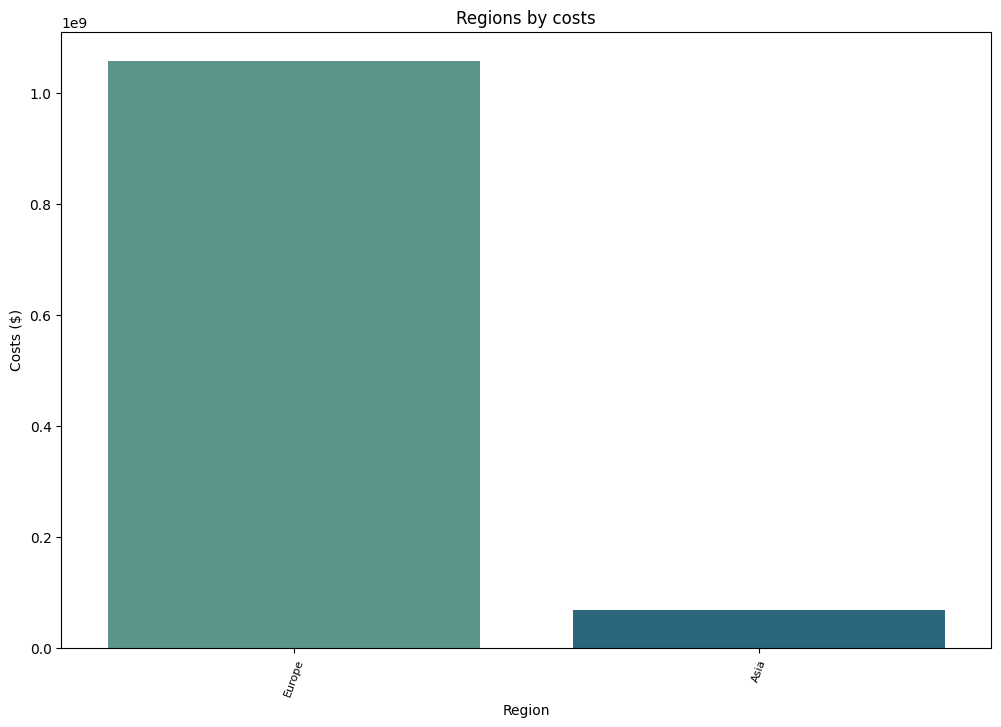

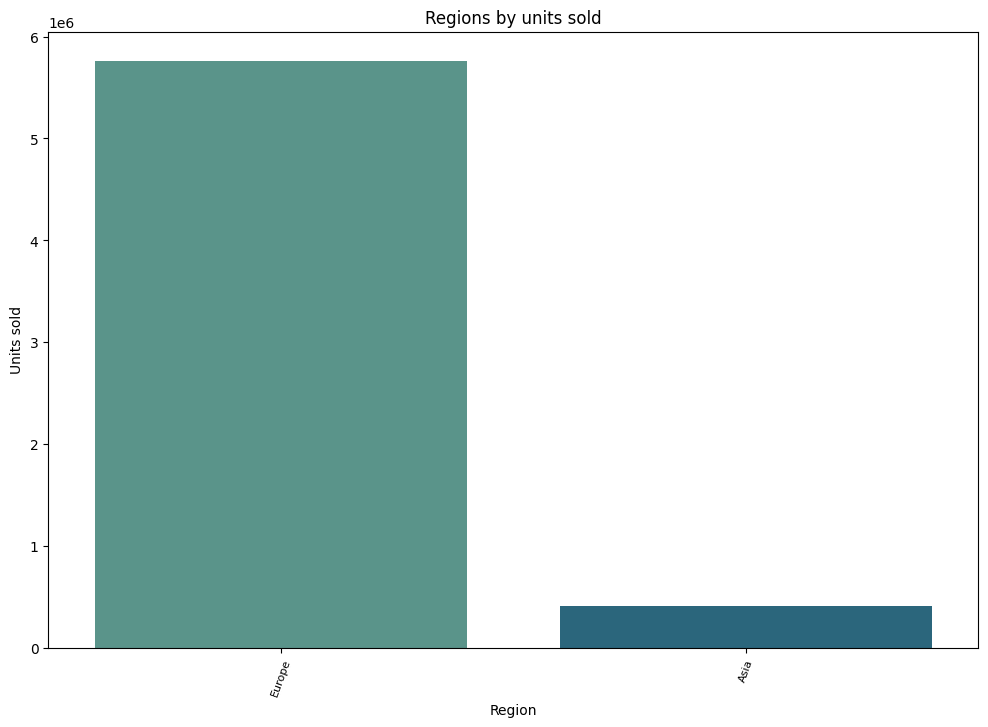

<Figure size 640x480 with 0 Axes>

Revenue by channel:
  sales_channel       revenue
0       offline  8.100305e+08
1        online  7.889533e+08.
Profit by channel:
  sales_channel        profit
0       offline  2.385113e+08
1        online  2.351977e+08.
Order cost by channel:
  sales_channel    order_cost
0       offline  5.715191e+08
1        online  5.537556e+08.
Popularity by channel:
  sales_channel  units_sold
0       offline   3113412.0
1        online   3058259.0.
  sales_channel       revenue
0       offline  8.100305e+08
1        online  7.889533e+08


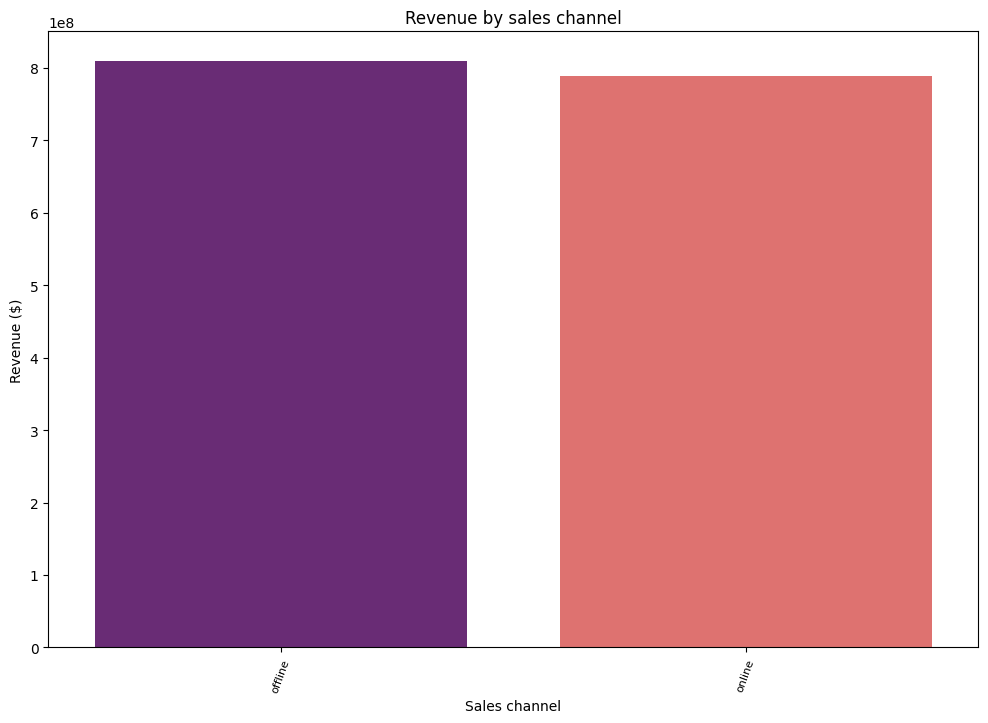

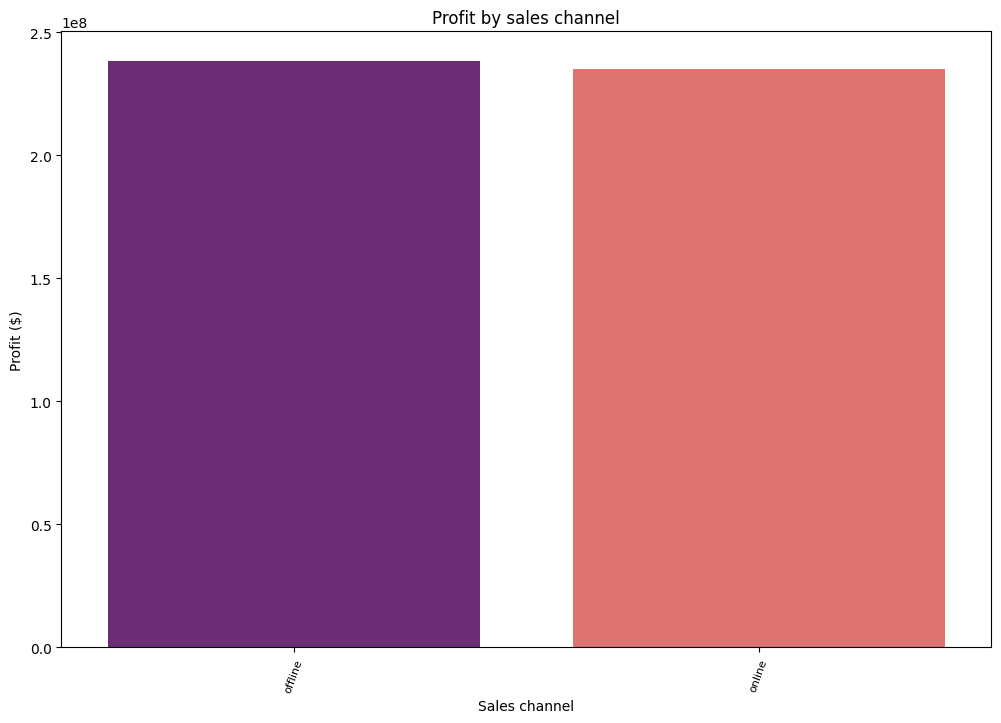

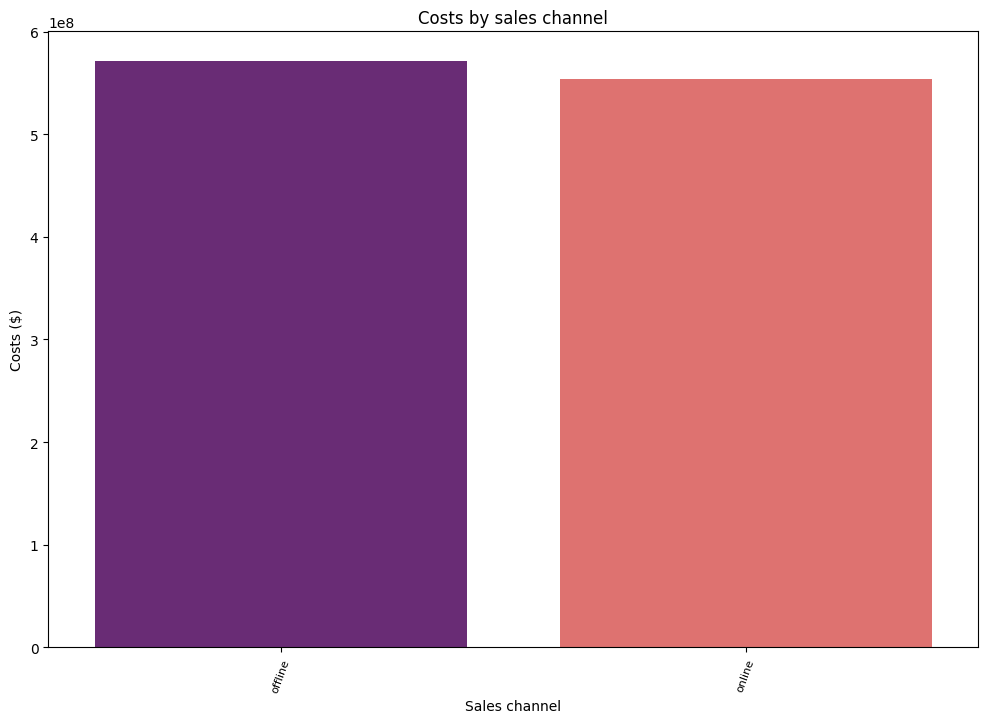

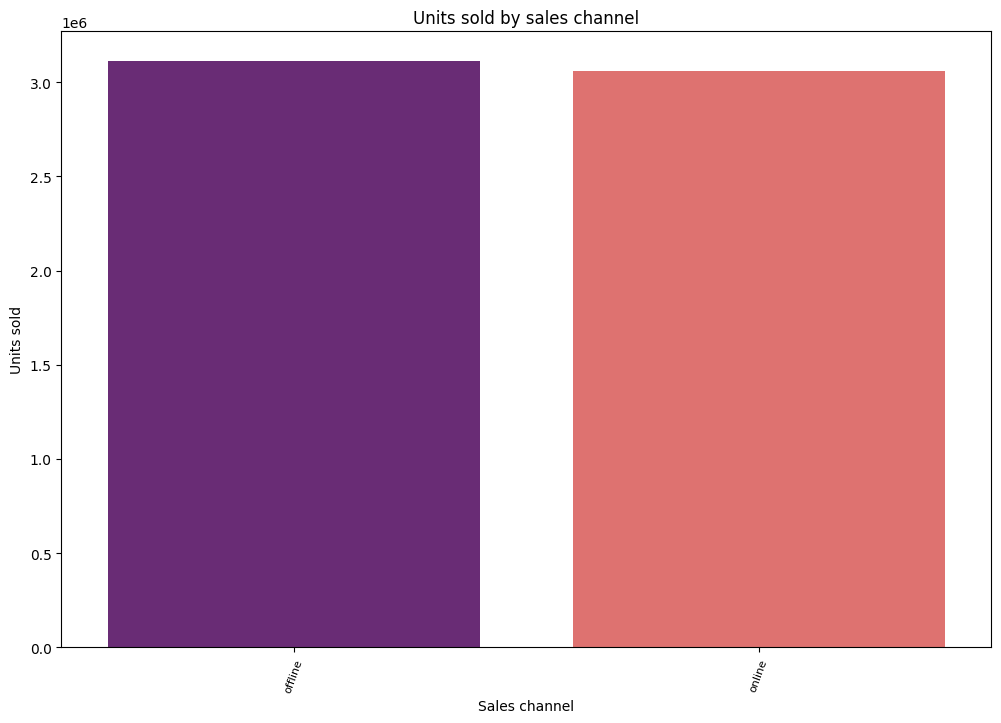

<Figure size 640x480 with 0 Axes>

In [ ]:
def metrics_by_grouped_df(df, value: str, index:str, agg_func: str):
  pivot_t = pd.pivot_table(df, values=value, index=index, aggfunc=agg_func).reset_index().sort_values(by=value, ascending=False)
  return pivot_t

revenue_by_items_group = metrics_by_grouped_df(joined_df, "revenue", "item_type", "sum")
profit_by_items_group = metrics_by_grouped_df(joined_df, "profit", "item_type", "sum")
order_cost_by_items_group = metrics_by_grouped_df(joined_df, "order_cost", "item_type", "sum")
popularity_by_items_group = metrics_by_grouped_df(joined_df, "units_sold", "item_type", "sum")
print(f"Revenue by items group:\n{revenue_by_items_group}.\nProfit by item group:\n{profit_by_items_group}.\nOrder cost by item group:\n{order_cost_by_items_group}.\nPopularity by item group:\n{popularity_by_items_group}.")

def create_plot(df, x_value: str, y_value: str, titl: str, xlab: str, ylab: str, palett: str):

  plt.figure(figsize=(12, 8))
  sns.barplot(data=df, x=x_value, y=y_value, hue=x_value, palette=palett)
  plt.title(titl)
  plt.xlabel(xlab)
  plt.ylabel(ylab)
  plt.tick_params(axis='x', rotation=70, labelsize=8)
  plt.show()


#plt.figure(figsize=(12, 8))

create_plot(profit_by_items_group, "item_type", "profit", "Profit by item type", "Item type", "Profit ($)", "viridis" )
create_plot(revenue_by_items_group, "item_type", "revenue", "Revenue by item type", "Item type", "Revenue ($)", "viridis" )
create_plot(order_cost_by_items_group, "item_type", "order_cost", "Costs by item type", "Item type", "Cost ($)", "viridis" )
create_plot(popularity_by_items_group, "item_type", "units_sold", "Popularity by item type", "Item type", "Items sold", "viridis" )
#plt.show()

# Продажі в розрізі країн та регіонів
def metrics_by_geography(df, value: str, index:str, agg_func: str):
  pivot_t = pd.pivot_table(df, values=value, index=index, aggfunc=agg_func).reset_index().sort_values(by=value, ascending=False).head(10)
  return pivot_t

top_10_countries_by_revenue = metrics_by_geography(joined_df, "revenue", "name", "sum")
top_10_countries_by_profit = metrics_by_geography(joined_df, "profit", "name", "sum")
top_10_countries_by_order_cost = metrics_by_geography(joined_df, "order_cost", "name", "sum")
top_10_countries_by_popularity = metrics_by_geography(joined_df, "units_sold", "name", "sum")
print(f"Revenue by countries:\n{top_10_countries_by_revenue}.\nProfit by countries:\n{top_10_countries_by_profit}.\nOrder cost by countries:\n{top_10_countries_by_order_cost}.\nPopularity by countries:\n{top_10_countries_by_popularity}.")

create_plot(top_10_countries_by_revenue, "name", "revenue", "Top-10 countries by revenue", "Name", "Revenue ($)", "magma" )
create_plot(top_10_countries_by_profit, "name", "profit", "Top-10 countries by profit", "Name", "Profit ($)", "magma"  )
create_plot(top_10_countries_by_order_cost, "name", "order_cost", "Top-10 countries by costs", "Name", "Cost ($)", "magma"   )
create_plot(top_10_countries_by_popularity, "name", "units_sold", "Top-10 countries by units sold", "Name", "Items sold", "magma"   )
plt.tight_layout()
plt.show()

regions_by_revenue = metrics_by_grouped_df(joined_df, "revenue", "region", "sum")
regions_by_profit = metrics_by_grouped_df(joined_df, "profit", "region", "sum")
regions_by_costs = metrics_by_grouped_df(joined_df, "order_cost", "region", "sum")
regions_by_popularity = metrics_by_grouped_df(joined_df, "units_sold", "region", "sum")
print(f"Revenue by regions:\n{regions_by_revenue}.\nProfit by regions:\n{regions_by_profit}.\nOrder cost by regions:\n{regions_by_costs}.\nPopularity by regions:\n{regions_by_popularity}.")


create_plot(regions_by_revenue, "region", "revenue", "Regions by revenue", "Region", "Revenue ($)", "crest" )
create_plot(regions_by_profit, "region", "profit", "Regions by profit", "Region", "Profit ($)", "crest" )
create_plot(regions_by_costs, "region", "order_cost", "Regions by costs", "Region", "Costs ($)", "crest" )
create_plot(regions_by_popularity, "region", "units_sold", "Regions by units sold", "Region", "Units sold", "crest" )
plt.tight_layout()
plt.show()

revenue_by_channel = metrics_by_grouped_df(joined_df, "revenue", "sales_channel", "sum")
profit_by_channel = metrics_by_grouped_df(joined_df, "profit", "sales_channel", "sum")
costs_by_channel = metrics_by_grouped_df(joined_df, "order_cost", "sales_channel", "sum")
popularity_by_channel = metrics_by_grouped_df(joined_df, "units_sold", "sales_channel", "sum")
print(f"Revenue by channel:\n{revenue_by_channel}.\nProfit by channel:\n{profit_by_channel}.\nOrder cost by channel:\n{costs_by_channel}.\nPopularity by channel:\n{popularity_by_channel}.")
print(revenue_by_channel)

create_plot(revenue_by_channel, "sales_channel", "revenue", "Revenue by sales channel", "Sales channel", "Revenue ($)", "magma" )
create_plot(profit_by_channel, "sales_channel", "profit", "Profit by sales channel", "Sales channel", "Profit ($)", "magma" )
create_plot(costs_by_channel, "sales_channel", "order_cost", "Costs by sales channel", "Sales channel", "Costs ($)", "magma" )
create_plot(popularity_by_channel, "sales_channel", "units_sold", "Units sold by sales channel", "Sales channel", "Units sold", "magma" )
plt.tight_layout()
plt.show()





### Aналіз інтервалу часу між замовленням та його відвантаженням.
# Аналіз інтервалу часу між замовленням та відвантаженням

## Аналіз по категоріях

- Найдовший час збирання замовлення мають категорії:
  - **Baby Food** — 29 днів
  - **Cereal** — 29 днів
  - **Office Supplies** — 28 днів
  - **Cosmetics** — 28 днів

- Найкоротший час збирання замовлення мають категорії:
  - **Clothes** — 21 день
  - **Personal Care** — 20 днів

---

## Аналіз по країнах

- Найшвидше відвантажують замовлення у країнах:
  - **Croatia** — 11 днів
  - **Estonia** — 17 днів
  - **Serbia** — 18 днів

- Найдовше відвантаження триває у країнах:
  - **Hungary** — 36 днів
  - **Russia** — 34 дні
  - **Monaco** — 33 дні

**Рекомендація:** потрібен подальший аналіз для визначення причин затримок із відвантаженням, а також пошук шляхів оптимізації логістичних процесів.

---

## Аналіз по регіонах

- Інтервал часу між замовленням та його відвантаженням по регіонах є практично однаковим:
  - **Asia** — 25.5 днів
  - **Europe** — 25.0 днів


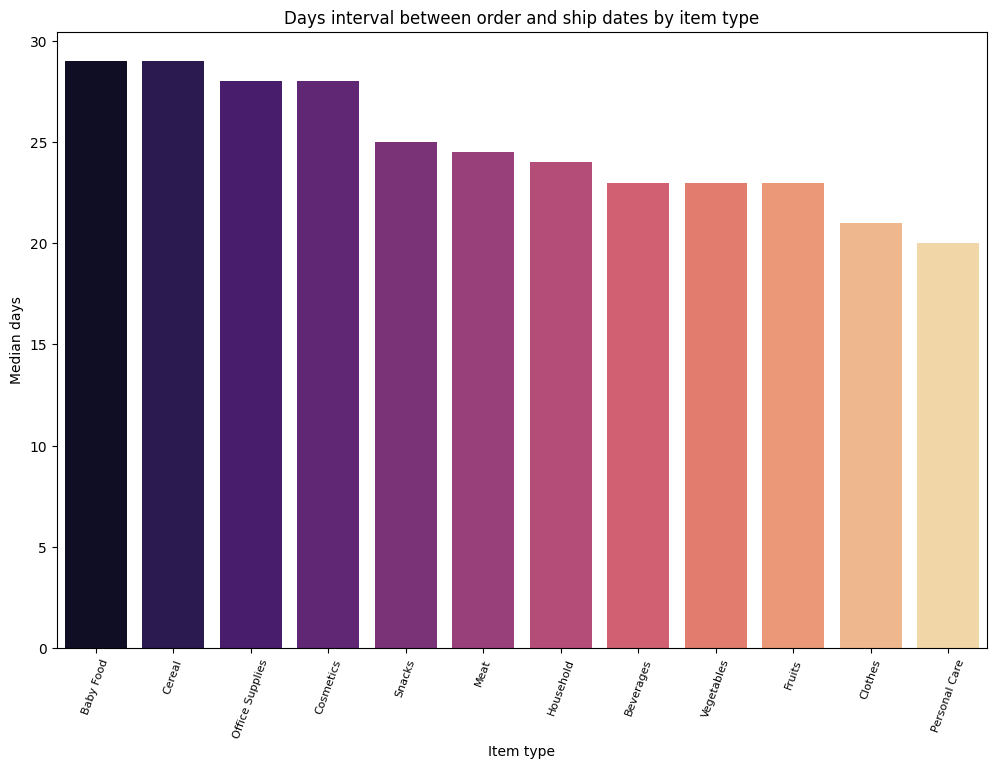

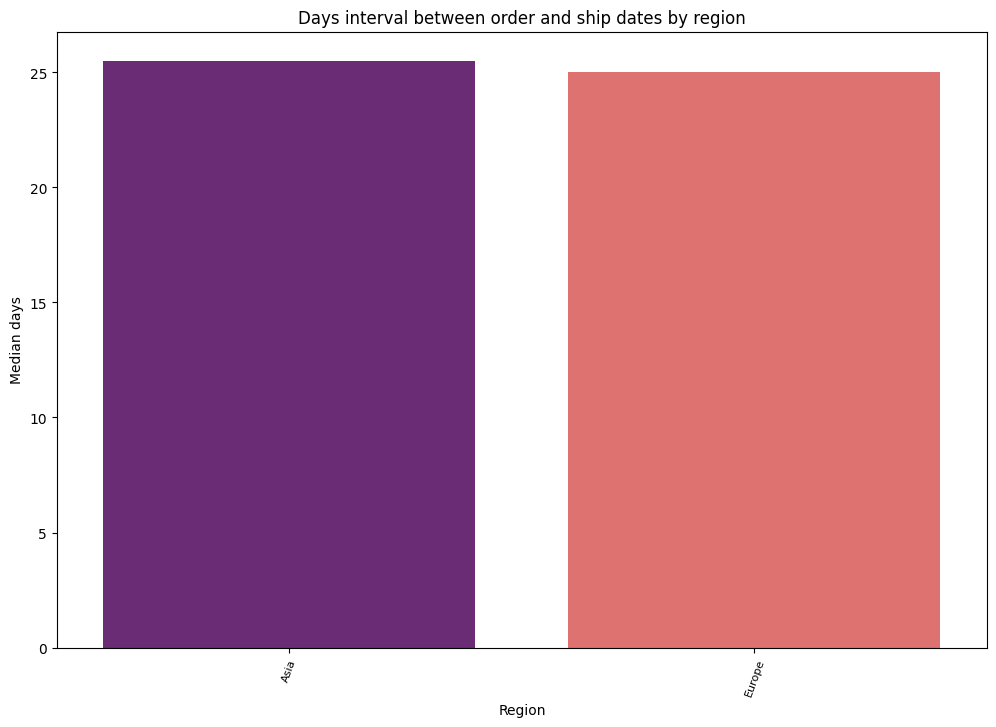

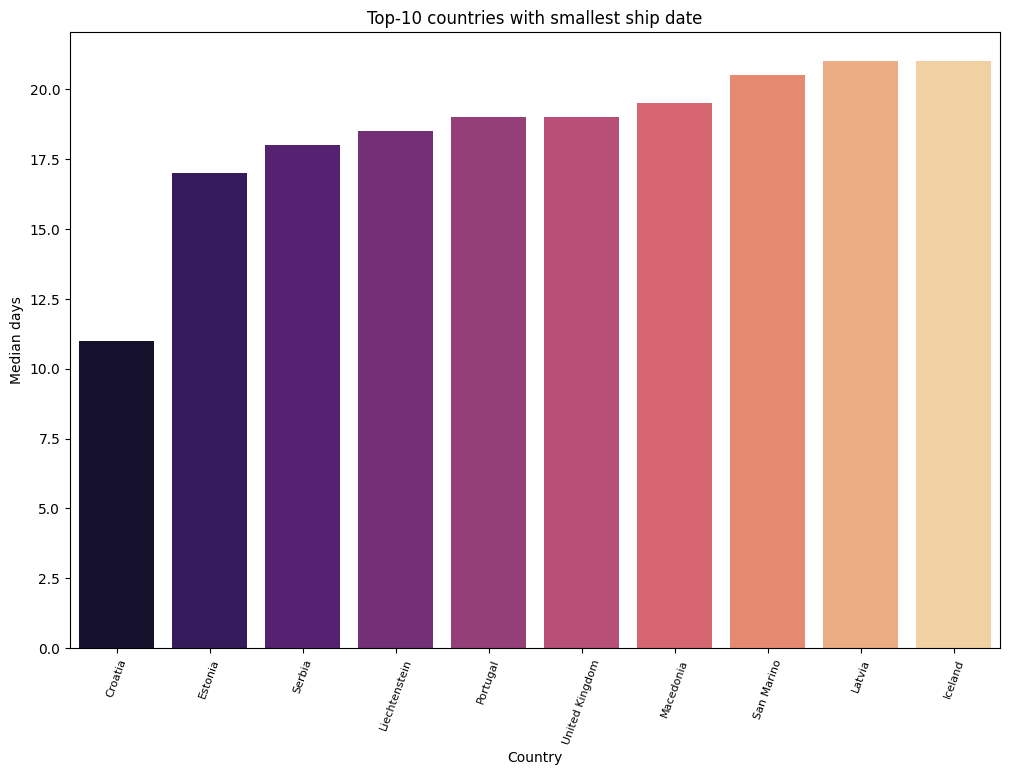

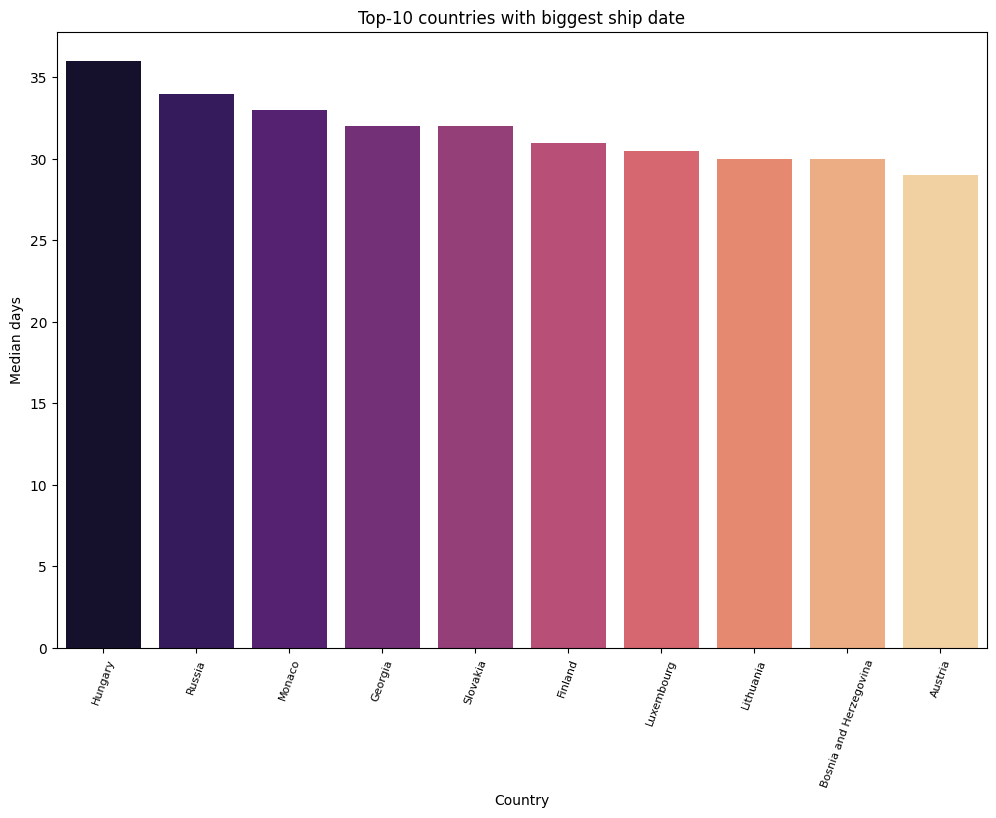

<Figure size 640x480 with 0 Axes>

Ship date by categories:
          item_type  interval_days
0         Baby Food           29.0
2            Cereal           29.0
8   Office Supplies           28.0
4         Cosmetics           28.0
10           Snacks           25.0
7              Meat           24.5
6         Household           24.0
1         Beverages           23.0
11       Vegetables           23.0
5            Fruits           23.0
3           Clothes           21.0
9     Personal Care           20.0.
Top-10 countries by ship date:
              name  interval_days
8          Croatia           11.0
12         Estonia           17.0
37          Serbia           18.0
23   Liechtenstein           18.5
33        Portugal           19.0
44  United Kingdom           19.0
26       Macedonia           19.5
36      San Marino           20.5
22          Latvia           21.0
19         Iceland           21.0.
Antitop-10 countries by ship days:
                      name  interval_days
18                 Hungary          

In [ ]:
joined_df["interval_days"] = (joined_df["ship_date"] - joined_df['order_date']).dt.days
grouped_by_categories = metrics_by_grouped_df(joined_df, "interval_days", "item_type", "median")
top_10_countries_by_ship_days = metrics_by_grouped_df(joined_df, "interval_days", "name", "median").sort_values(by="interval_days").head(10)
anti_top_10_countries_by_ship_days = metrics_by_grouped_df(joined_df, "interval_days", "name", "median").sort_values(by="interval_days", ascending=False).head(10)
grouped_by_regions = metrics_by_grouped_df(joined_df, "interval_days", "region", "median")
create_plot(grouped_by_categories, "item_type", "interval_days", "Days interval between order and ship dates by item type", "Item type", "Median days", "magma" )
create_plot(grouped_by_regions, "region", "interval_days", "Days interval between order and ship dates by region", "Region", "Median days", "magma" )
create_plot(top_10_countries_by_ship_days, "name", "interval_days", "Top-10 countries with smallest ship date", "Country", "Median days", "magma" )
create_plot(anti_top_10_countries_by_ship_days, "name", "interval_days", "Top-10 countries with biggest ship date", "Country", "Median days", "magma" )

plt.tight_layout()
plt.show()

print(f"Ship date by categories:\n{grouped_by_categories}.\nTop-10 countries by ship date:\n{top_10_countries_by_ship_days}.\nAntitop-10 countries by ship days:\n{anti_top_10_countries_by_ship_days}.\nShip date by regions:\n{grouped_by_regions}")



## Аналіз залежності прибутку від часу, необхідного на відвантаження товару.
Кореляції між часом потрібними для відвантаження товару та прибутком не виявлено.


                       sum           mean  count
interval_days                                   
0               6419878.24  337888.328421     19
1               6429428.34  338390.965263     19
2               8664755.51  346590.220400     25
3               8847142.49  285391.693226     31
4               7527863.59  278809.762593     27
5              11276412.01  417644.889259     27
6               9517301.39  366050.053462     26
7              11953246.37  398441.545667     30
8               8164725.51  354988.065652     23
9              11585602.57  445600.098846     26
10              3397577.40  212348.587500     16
11             10739042.85  413040.109615     26
12              9589547.08  368828.733846     26
13              6108834.05  321517.581579     19
14              7371059.48  307127.478333     24
15              8239716.51  294275.589643     28
16             12843610.64  428120.354667     30
17             11476296.16  441396.006154     26
18              3195

/tmp/ipykernel_4572/1287407087.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=groupby_order_aging, x="interval_days", y="sum", palette="viridis")


<Axes: xlabel='interval_days', ylabel='sum'>

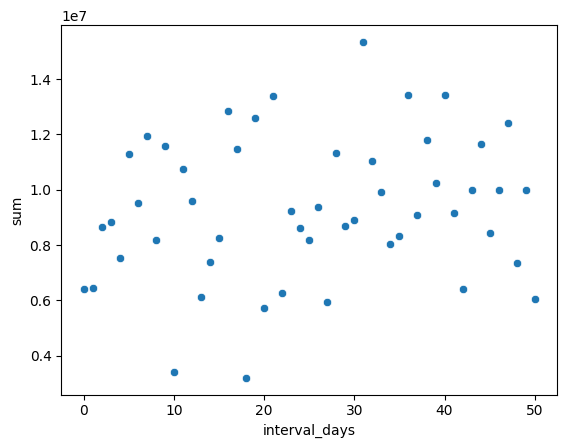

In [ ]:
groupby_order_aging = joined_df.groupby("interval_days")["profit"].agg(["sum", "mean", "count"])
groupby_order_aging.columns=["sum", "mean", "count"]
print(groupby_order_aging)
sns.scatterplot(data=groupby_order_aging, x="interval_days", y="sum", palette="viridis")



##  Динаміка продажів (у часі) у розрізі категорій товарів, країн, регіонів.
# Основні тенденції динаміки продажів.

### Основні висновки по категоріях:

### А. Високодохідні категорії (Драйвери прибутку)
* **Office Supplies (Офісні товари):** Ключова категорія. Незважаючи на коливання, вона генерує найбільший обсяг виручки, досягнувши піку у 2015 році (понад $65 млн).  

* **Household (Товари для дому):** Демонструє впевнені показники, тримаючись переважно в діапазоні $30–43 млн.  

* **Cosmetics (Косметика):** Після аномального сплеску у 2012 році ($55 млн) та подальшої корекції, категорія демонструє ознаки відновлення зростання у 2017 році (з урахуванням лише 7 місяців).

### Б. Категорії зі спадним трендом
* **Cereal (Зернові):** Спостерігається стійка негативна динаміка з 2010 року. Продажі впали з ~$17.5 млн до критично низьких значень.
* **Personal Care (Особиста гігієна):** Поступове та стабільне зниження частки ринку протягом усього періоду.
* **Baby Food (Дитяче харчування):** Помітне падіння почалося після 2015 року.

### В. Волатильні та стабільні категорії
* **Clothes (Одяг) & Snacks (Снеки):** Мають "пилкоподібний" графік. Виручка різко змінюється рік до року, що вказує на високу чутливість до сезонів або промо-акцій.
* **Vegetables (Овочі) & Beverages (Напої):** Стабільні категорії з помірною виручкою. Овочі показали локальний пік у 2011 році, після чого стабілізувалися.
* **Fruits (Фрукти):** Найнижчий рівень доходу з усіх категорій, тренд практично незмінний .

### Категорії-лідери за виручкою

1. Office Supplies — до **$67.5 млн**  

2. Household — до **$43.7 млн**  

3. Meat — до **$32.4 млн**



## У розрізі регіонів:

* **Europe (Європа):** Основний драйвер бізнесу.
* **Пік:** 2012 рік (близько $2.45*10^8$).
* **Тренд:** Висока волатильність із циклічними спадами (2013 та 2016 роки). Падіння у 2017 році зумовлене неповним звітним періодом (7 місяців).


* **Asia (Азія):** Регіон зі стабільно низькою часткою в портфелі. Показники залишаються майже незмінними протягом 7 років, що свідчить про відсутність активної експансії або низьке проникнення продукту на цей ринок.



---
## У розрізі країн:

Графік демонструє «проєктний» характер продажів у Чехії, Україні та Боснії і Герцеговині, де періоди надвисоких прибутків чергуються з різкими спадами.

1. **Боснія і Герцеговина:** Лідер за потенційною виручкою в окремі роки, проте демонструє найменшу стабільність. Кожні два роки (2012, 2014, 2016) спостерігається глибоке падіння.
2. **Україна:** Єдина країна, де показник за **7 місяців 2017 року** вже вищий за результат повного **2016 року**. Це вказує на зміну ринкової частки або успішну реалізацію великого контракту на початку року.
3. **Чехія:** Потребує перегляду стратегії, оскільки з 2014 року кожен наступний рік демонструє нижчі показники, ніж попередній.



                      name      revenue
10          Czech Republic  53543932.14
43                 Ukraine  53252317.54
6   Bosnia and Herzegovina  50117508.49
Names list:['Czech Republic' 'Ukraine' 'Bosnia and Herzegovina']


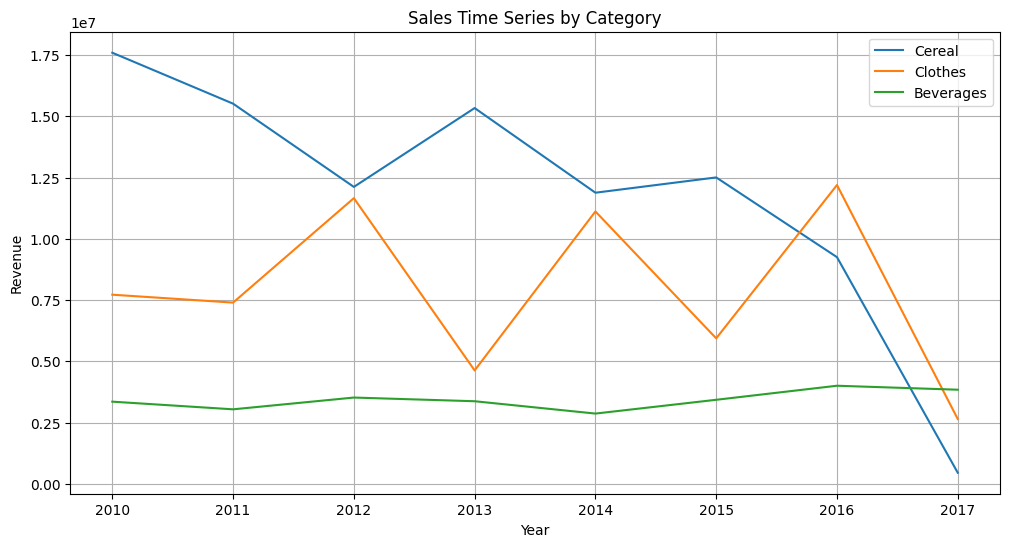

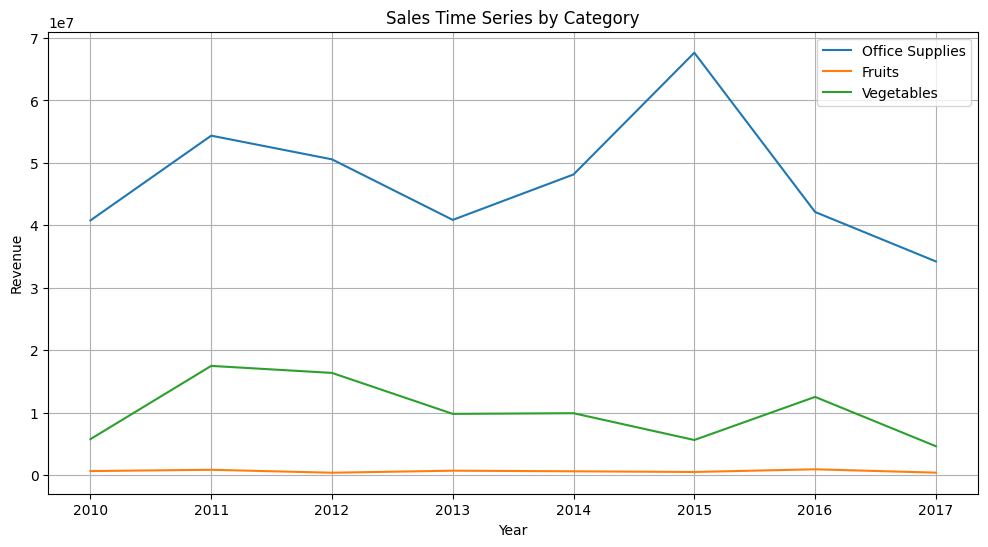

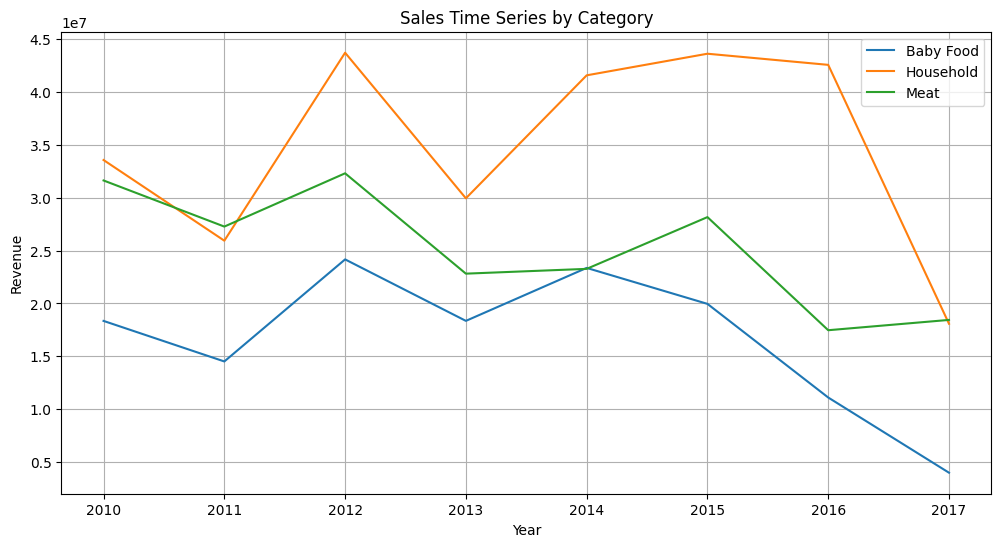

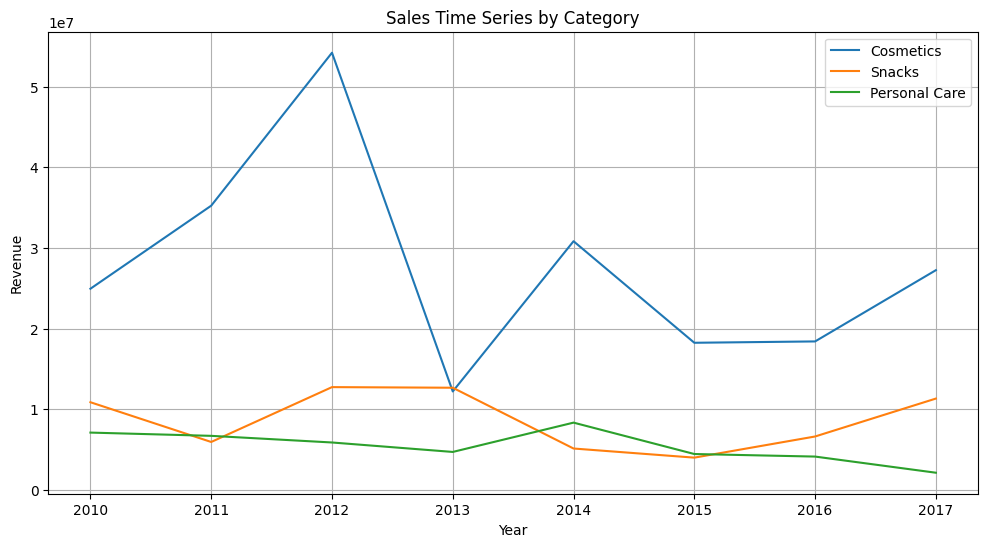

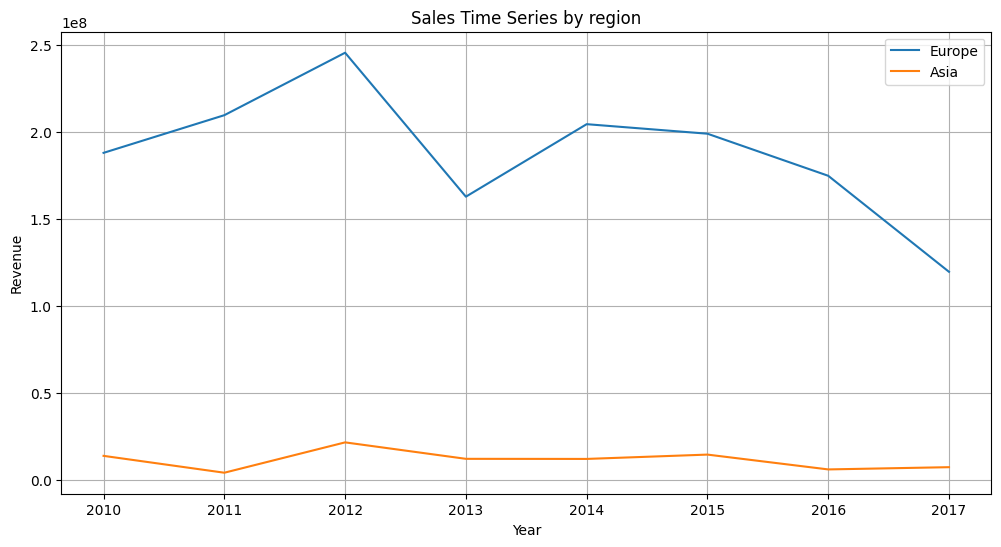

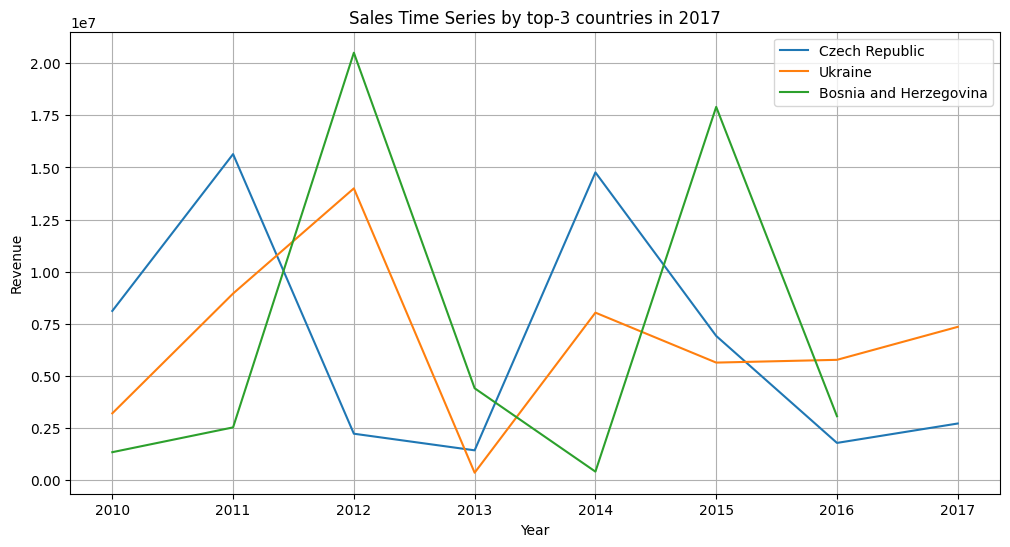

In [ ]:
joined_df["year"] = joined_df["order_date"].dt.year
grouped_by_year_item_type = joined_df.groupby(["year", "item_type"])["revenue"].sum().reset_index()

time_series_regions = joined_df.groupby(["region", "year"])["revenue"].sum().reset_index()

joined_df_2017 = joined_df[joined_df["order_date"].dt.year ==2017]
joined_df_2016 = joined_df[joined_df["order_date"].dt.year ==2016]
time_series_countries = joined_df.groupby(["name", "year"])["revenue"].sum().reset_index()

categories_1 = joined_df["item_type"].unique()[:3]
categories_2 = joined_df["item_type"].unique()[3:6]
categories_3 = joined_df["item_type"].unique()[6:9]
categories_4 = joined_df["item_type"].unique()[9:]
regions = joined_df["region"].unique()

top_3_revenue_countries = joined_df.groupby("name")["revenue"].sum().reset_index().sort_values(by="revenue", ascending=False).head(3)

print(top_3_revenue_countries)
countries_names = top_3_revenue_countries["name"].unique()
print(f"Names list:{countries_names}")


# Динаміка продажів по категоріях
plt.figure(figsize=(12, 6))
for category in categories_1:
    categories_data = grouped_by_year_item_type[grouped_by_year_item_type["item_type"] == category]
    plt.plot(categories_data["year"], categories_data["revenue"], label=category)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by Category")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for category in categories_2:
    categories_data = grouped_by_year_item_type[grouped_by_year_item_type["item_type"] == category]
    plt.plot(categories_data["year"], categories_data["revenue"], label=category)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by Category")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for category in categories_3:
    categories_data = grouped_by_year_item_type[grouped_by_year_item_type["item_type"] == category]
    plt.plot(categories_data["year"], categories_data["revenue"], label=category)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by Category")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for category in categories_4:
    categories_data = grouped_by_year_item_type[grouped_by_year_item_type["item_type"] == category]
    plt.plot(categories_data["year"], categories_data["revenue"], label=category)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by Category")
plt.legend()
plt.grid(True)
plt.show()


# Динаміка продажів по регіонах
plt.figure(figsize=(12, 6))
for region in regions:
    regions_data = time_series_regions[time_series_regions["region"] == region]
    plt.plot(regions_data["year"], regions_data["revenue"], label=region)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by region")
plt.legend()
plt.grid(True)
plt.show()

# Динаміка продажів у  топ-3 країнах за 2017 рік .

plt.figure(figsize=(12, 6))
for country in countries_names:
    countries_data = time_series_countries[time_series_countries["name"] == country]
    plt.plot(countries_data["year"], countries_data["revenue"], label = country)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales Time Series by top-3 countries in 2017")
plt.legend()
plt.grid(True)
plt.show()



## Аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?
# Аналіз продажів по днях тижня

## Найбільш прибуткові дні

Найбільші загальні виторги припадають на:

- **Понеділок** — \(2.591551*10^8$)  

- **Середу** — (2.448676*10^8$)  

- **П’ятницю** — \(2.436208*10^8$)

---

## Сезонність категорій по днях тижня

- **Cereal** — найбільші виторги припадають на вихідні.
- **Vegetables** — найбільші виторги спостерігаються у неділю та понеділок.
- **Clothes** — найбільші виторги припадають на вихідні та вівторок.
- **Snacks** — найбільші виторги спостерігаються у суботу та понеділок.
- **Personal Care** — найбільші виторги припадають на вихідні та середу.
- **Meat** — найбільші виторги спостерігаються у першій половині тижня та в суботу.
- **Baby Food** — найбільші виторги припадають на другу половину тижня та вівторок.
- **Fruits** — найбільше продажів спостерігається у вихідні.


/tmp/ipykernel_3988/2743442592.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_day_of_week = joined_df.groupby("day_of_week")["revenue"].sum().reset_index().sort_values(by="day_of_week")
/tmp/ipykernel_3988/2743442592.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_day_of_week_and_category = joined_df.groupby(["day_of_week", "item_type"])["revenue"].sum().reset_index().sort_values(by="day_of_week")
/tmp/ipykernel_3988/2743442592.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is calle

['Cereal' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits' 'Vegetables'
 'Baby Food' 'Household' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']
  day_of_week       revenue
0      Monday  2.591551e+08
1     Tuesday  2.048675e+08
2   Wednesday  2.448676e+08
3    Thursday  2.032473e+08
4      Friday  2.436208e+08
5    Saturday  2.208222e+08
6      Sunday  2.224033e+08


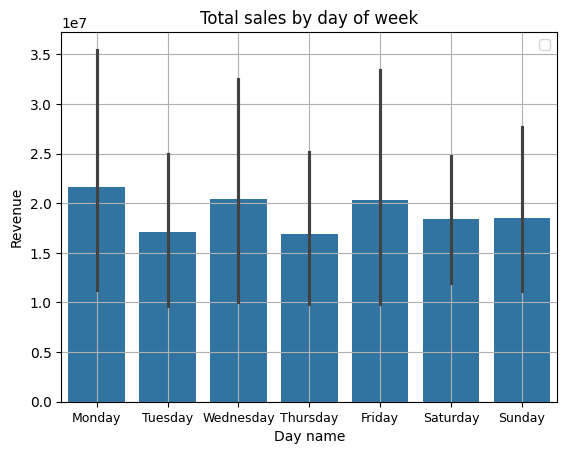

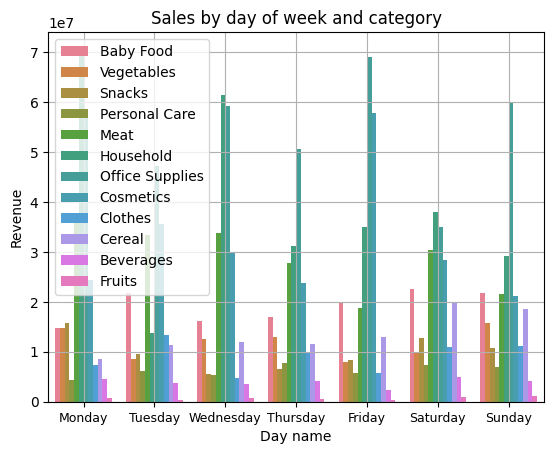

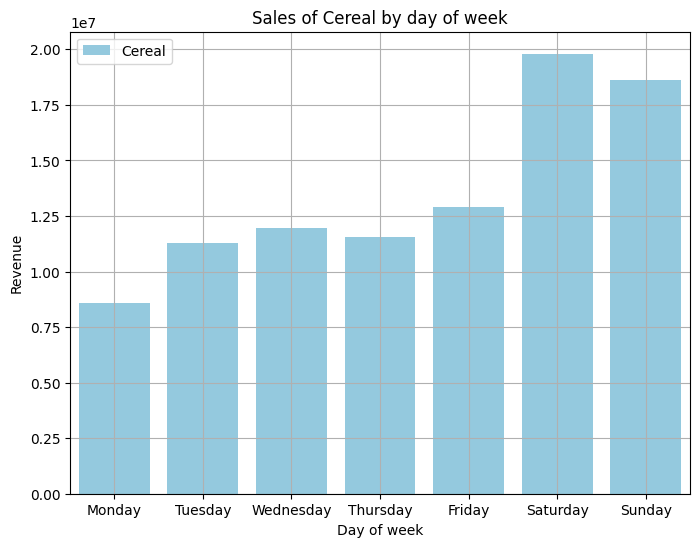

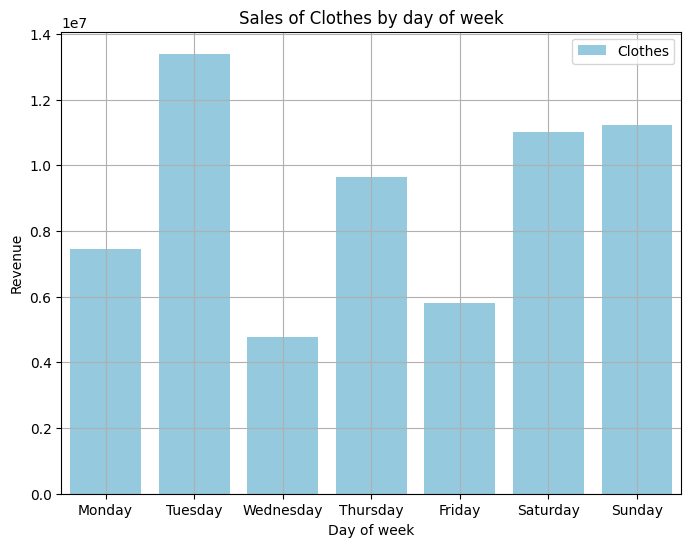

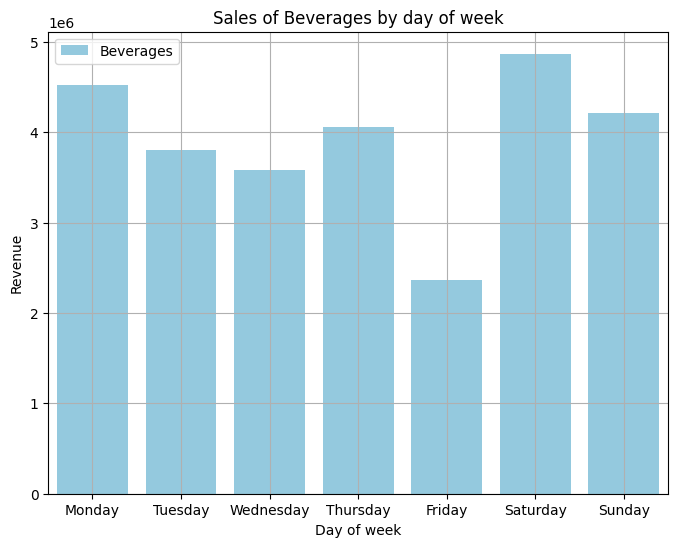

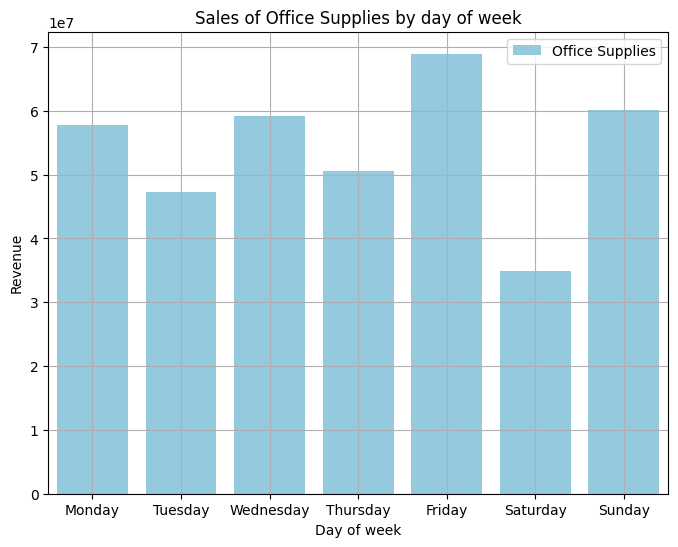

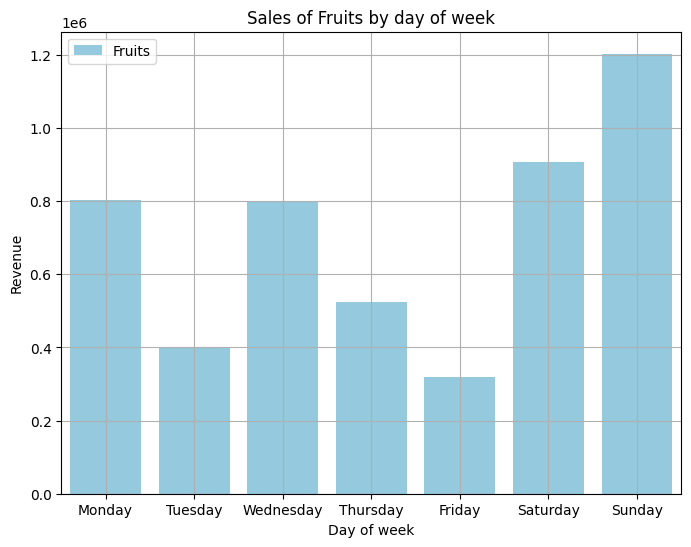

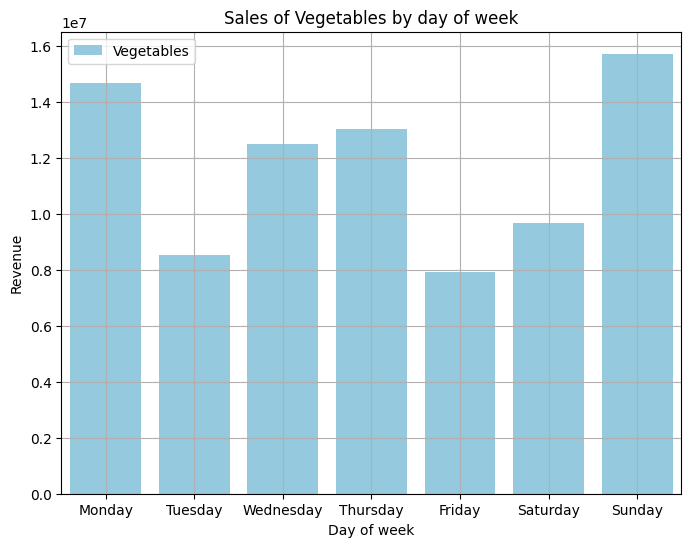

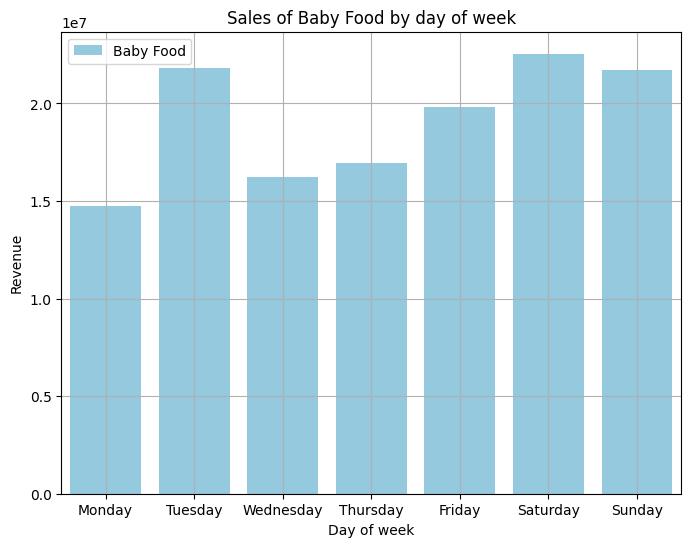

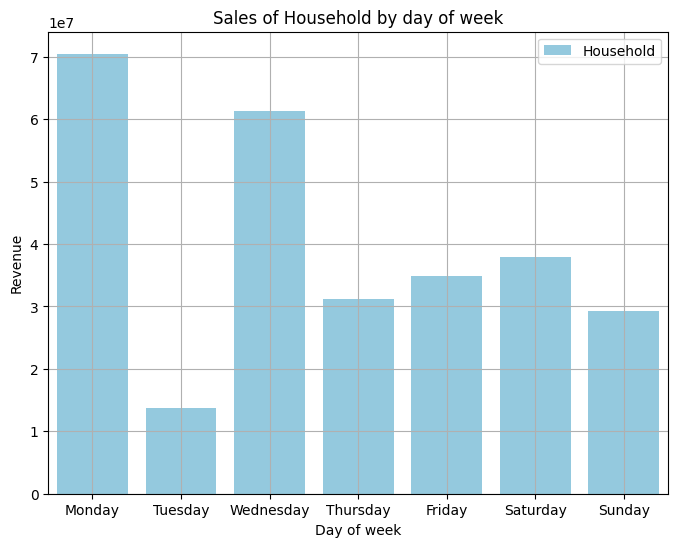

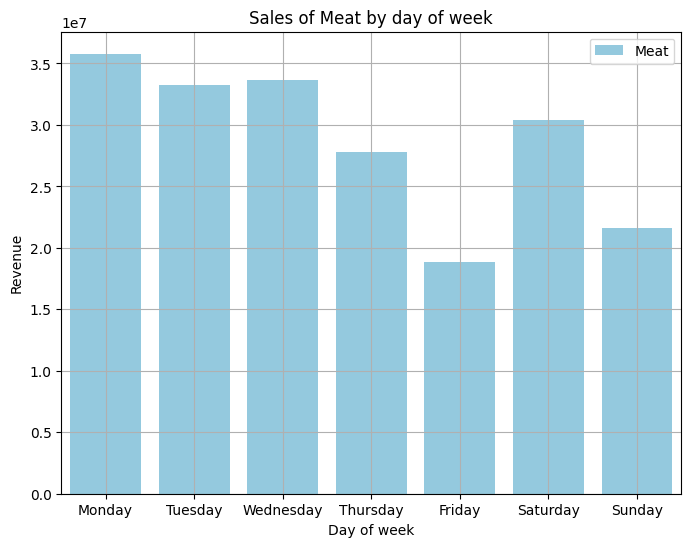

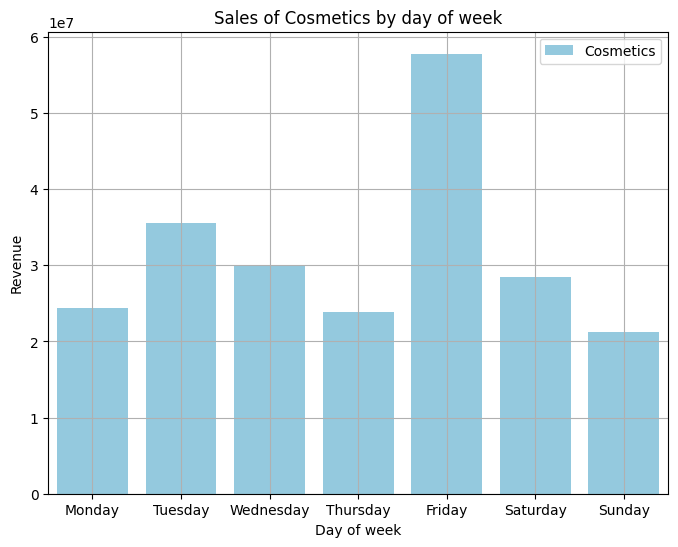

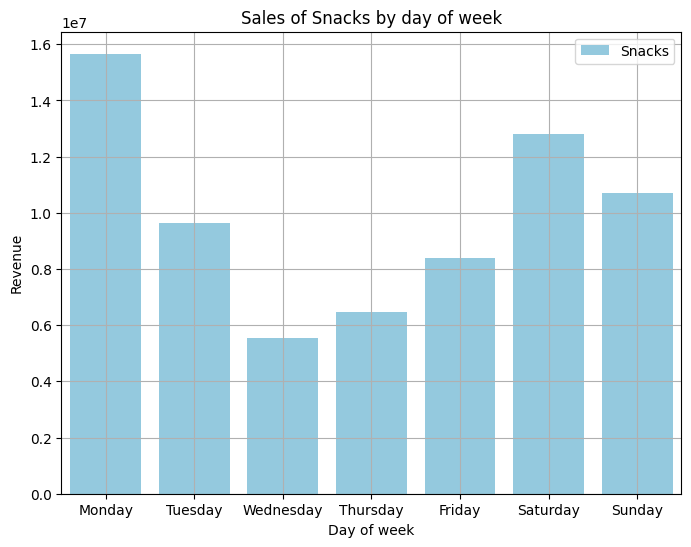

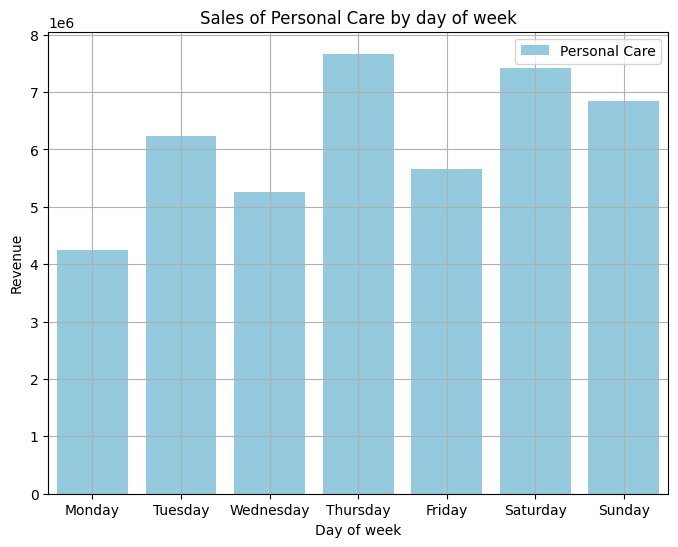

In [ ]:
joined_df["day_of_week"] = joined_df["order_date"].dt.day_name()
names_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
joined_df["day_of_week"] = pd.Categorical(joined_df["day_of_week"], categories=names_order, ordered=True)
sales_by_day_of_week = joined_df.groupby("day_of_week")["revenue"].sum().reset_index().sort_values(by="day_of_week")
sales_by_day_of_week_and_category = joined_df.groupby(["day_of_week", "item_type"])["revenue"].sum().reset_index().sort_values(by="day_of_week")
categories = joined_df["item_type"].unique()
print(categories)
print(sales_by_day_of_week)

sns.barplot(data=sales_by_day_of_week_and_category, x="day_of_week", y="revenue")
plt.xlabel("Day name")
plt.ylabel("Revenue")
plt.title("Total sales by day of week")
plt.legend()
plt.grid(True)
plt.tick_params(axis='x', labelsize=9)
plt.show()

sns.barplot(data=sales_by_day_of_week_and_category, x="day_of_week", y="revenue", hue="item_type")
plt.xlabel("Day name")
plt.ylabel("Revenue")
plt.title("Sales by day of week and category")
plt.legend()
plt.grid(True)
plt.tick_params(axis='x', labelsize=9)
plt.show()


for category in categories:
    plt.figure(figsize=(8, 6))
    categories_data = sales_by_day_of_week_and_category[sales_by_day_of_week_and_category["item_type"] == category]
    sns.barplot(data=categories_data, x="day_of_week", y="revenue", label = category, color="skyblue")
    plt.xlabel("Day of week")
    plt.ylabel("Revenue")
    plt.title(f"Sales of {category} by day of week")
    plt.legend()
    plt.grid(True)
    plt.show()



## Загальні висновки.
У результаті розвідувального аналізу встановлено, що найбільші прибутки приносять категорії :
- Cosmetics
- Office supplies
- Household.
 Рекомендовано розширювати асортимент та записи саме цих категорій у майбутньому.
 А категорія Fruits є найменш прибутковою , тому варто поступово виводити її з обігу.

 Країни : Ukraine , Andorra, Malta приносять найбільші прибутки. Водночас Andorra, Malta не входять у топ-3 за виторгами . Варто розвиватися у цих країнах з високою маржинальністю.

Країни Hungary, Russia, Monaco мають найдовший середній час між датою замовлення та датою відправки. Потрібен подальший аналіз для визначення причин та пошук шляхів  оптимізації  логістичних процесів.